In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
import matplotlib.gridspec as gridspec
import os

In [2]:
# Load data 
df = pd.read_excel(
    "/Users/annabelshinichen/Desktop/SchoolWork/MSBMI/Davoli_lab/TCGA/Resubmission_SCNAs/TableS1_TCGA_SampleNum_IS_Regressions_Tables.xlsx",
    sheet_name="IS_LinReg_CytobandCNV"
)

print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
print('Unique ImmuneHit:', df['ImmuneHit'].unique())
print('Unique cnv_status:', df['cnv_status'].unique())

Shape: (42718, 14)
Columns: ['TumorType', 'Chromosome', 'Arm', 'ChrArm', 'Cytoband', 'Coefficients', 'T_val', 'P_val', 'pval_signif', 'FDR', 'signed (-log(P.adj))', 'cnv_status', 'plot_hit', 'ImmuneHit']
Unique ImmuneHit: [nan 'Immune Cold' 'Immune Hot']
Unique cnv_status: [-1  1]


In [3]:
# ── Colormaps ─────────────────────────────────────────────────────────────────
cmap_pink = sns.light_palette("#EA6A6A", as_cmap=True)  # gain panels
cmap_blue = sns.light_palette("#4F6DB8", as_cmap=True)  # loss panels

In [5]:
# ── Output directory ──────────────────────────────────────────────────────────
out_dir = "/Users/annabelshinichen/Desktop/SchoolWork/MSBMI/Davoli_lab/TCGA/Resubmission_SCNAs"

# ── Tumor types per panel ─────────────────────────────────────────────────────
tumor_types_1q_gain  = ['BLCA', 'BRCA.neg', 'ESCA.AD', 'LUAD', 'OV', 'PAAD', 'SKCM', 'UCEC.MSI', 'KIRC']
tumor_types_17q_gain = ['BRCA.neg', 'GBM', 'LIHC', 'LUAD', 'SKCM', 'UVM']
tumor_types_1p_loss  = ['BRCA.neg', 'CESC', 'KIRC', 'LGG', 'PRAD', 'SARC', 'SKCM', 'STAD', 'UVM']
tumor_types_9p_loss  = ['BLCA', 'BRCA.pos', 'HNSC.HPVneg', 'LUAD', 'PAAD', 'KIRC']

panels = [
    {
        "title": "Chr1q Gain",
        "arm": "1q",
        "cnv": 1,
        "cmap": cmap_pink,
        "tumor_types": tumor_types_1q_gain,
        "filename": "cytoband_1q_gain_updated.pdf",
    },
    {
        "title": "Chr17q Gain",
        "arm": "17q",
        "cnv": 1,
        "cmap": cmap_pink,
        "tumor_types": tumor_types_17q_gain,
        "filename": "cytoband_17q_gain.pdf",
    },
    {
        "title": "Chr1p Loss",
        "arm": "1p",
        "cnv": -1,
        "cmap": cmap_blue,
        "tumor_types": tumor_types_1p_loss,
        "filename": "cytoband_1p_loss.pdf",
    },
    {
        "title": "Chr9p Loss",
        "arm": "9p",
        "cnv": -1,
        "cmap": cmap_blue,
        "tumor_types": tumor_types_9p_loss,
        "filename": "cytoband_9p_loss_updated.pdf",
    },
]

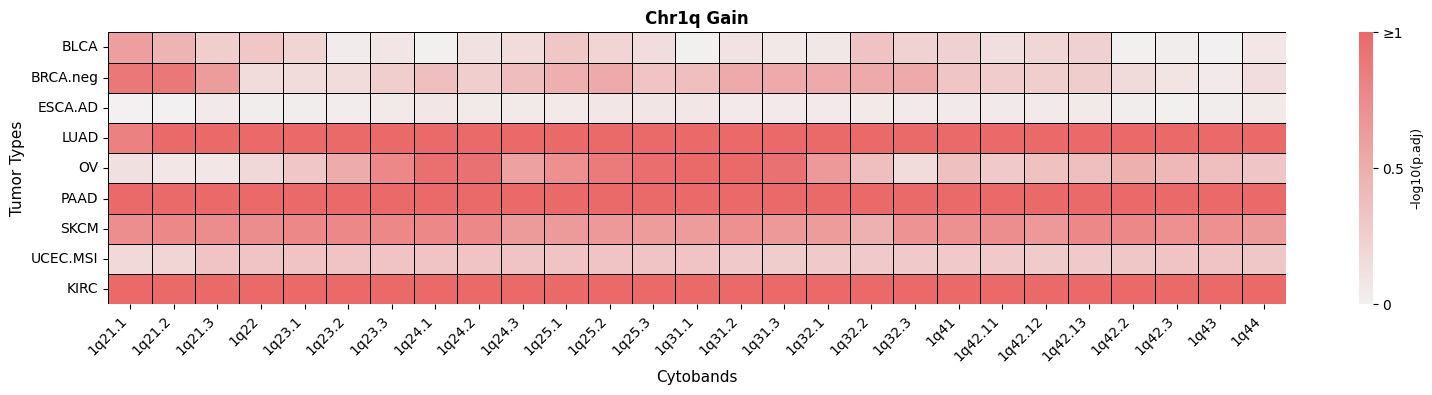

Saved: cytoband_1q_gain_updated.pdf


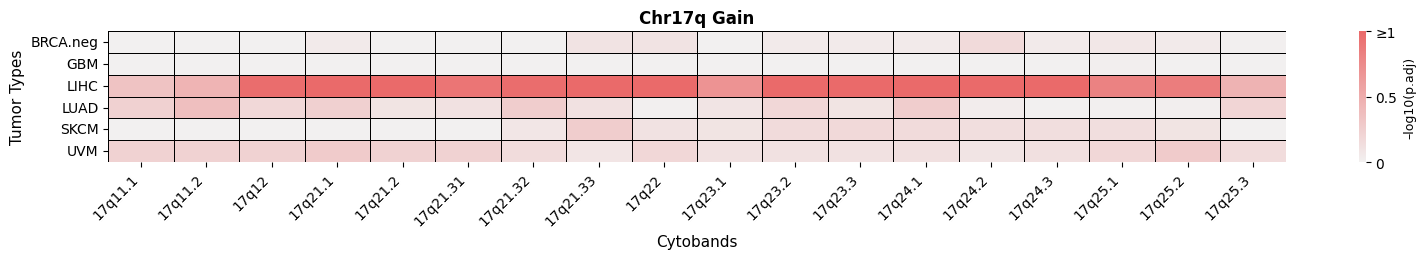

Saved: cytoband_17q_gain.pdf


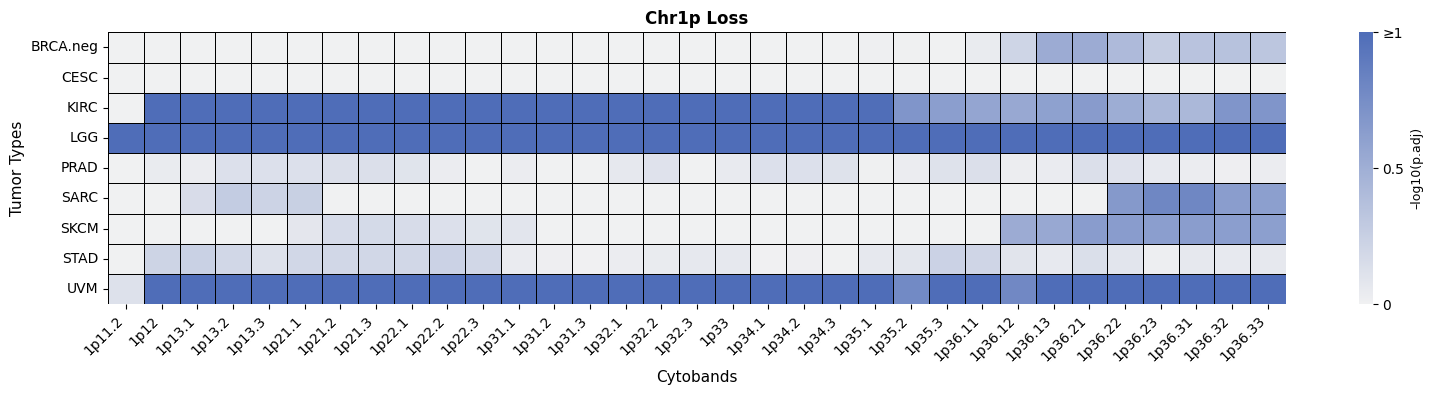

Saved: cytoband_1p_loss.pdf


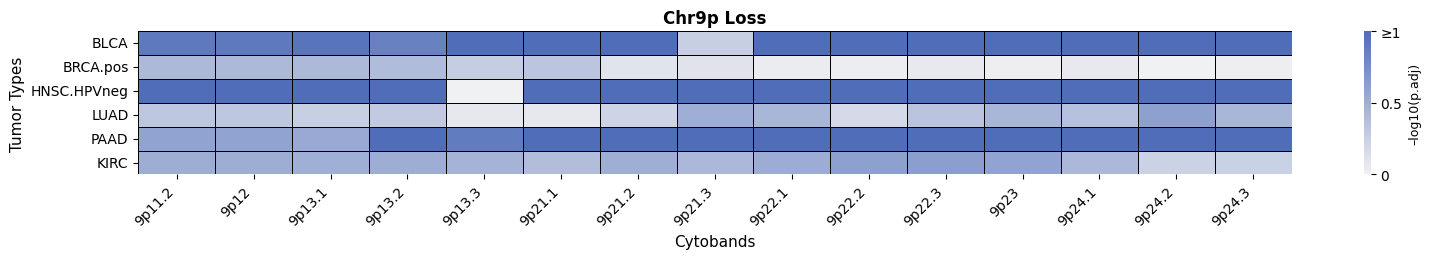

Saved: cytoband_9p_loss_updated.pdf


In [6]:
# ── Plot each panel — ALL hits, no ImmuneHit filter ───────────────────────────
# Values are already -log10(p.adj) so they are already log scaled
# We take abs() so magnitude is always positive (0 to 4)
# Pink = gain panel, Blue = loss panel (set per panel, not per value)

for panel in panels:

    filtered = df[
        # NO ImmuneHit filter — plot all cytobands regardless of significance
        (df['cnv_status'] == panel['cnv']) &
        (df['Cytoband'].str.startswith(panel['arm'])) &
        (df['TumorType'].isin(panel['tumor_types']))
    ].copy()

    # Use absolute value — values are already log10 transformed
    # abs() ensures all values are positive (0 to 4) for one-directional colormap
    filtered['plot_value'] = filtered['signed (-log(P.adj))'].abs()

    # Handle duplicates
    filtered = filtered.groupby(
        ["TumorType", "Cytoband"], as_index=False
    )["plot_value"].mean()

    # Pivot and enforce row order
    pivot = filtered.pivot(
        index="TumorType",
        columns="Cytoband",
        values="plot_value"
    ).fillna(0)
    pivot = pivot.reindex(panel['tumor_types']).fillna(0)

    # Plot
    n_rows = len(panel['tumor_types'])
    fig_height = max(2.5, n_rows * 0.45)

    fig, ax = plt.subplots(figsize=(16, fig_height))
    g = sns.heatmap(
        pivot,
        cmap=panel['cmap'],
        vmin=0, vmax=1,
        linewidths=0.5,
        linecolor='black',
        cbar_kws={
            "label": "–log10(p.adj)",
            "ticks": [0, 0.5, 1]
        },
        ax=ax
    )

    # Update colorbar to show p-value equivalents on right, -log10 on left
    cbar = g.collections[0].colorbar
    cbar.set_ticklabels(['0', '0.5', '≥1'])
    cbar.set_label('–log10(p.adj)', fontsize=9)

    plt.title(panel['title'], fontsize=12, fontweight='bold')
    plt.xlabel("Cytobands", fontsize=11)
    plt.ylabel("Tumor Types", fontsize=11)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, panel['filename']), format="pdf", bbox_inches="tight")
    plt.show()
    print(f"Saved: {panel['filename']}")

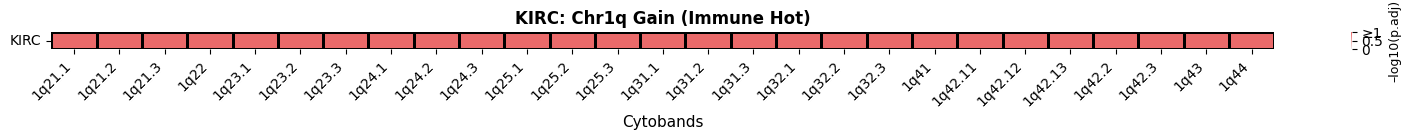

Saved: KIRC_1q_gain_hot.pdf


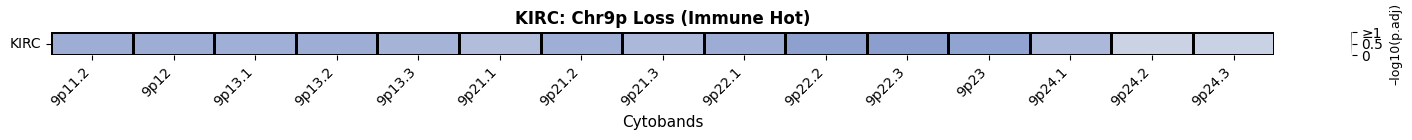

Saved: KIRC_9p_loss_hot.pdf


In [10]:
# ── KIRC: opposite trend — Immune Hot for 1q Gain and 9p Loss ─────────────────
# KIRC shows opposite association: these CNV events → immune HOT (not cold)
# Plotted separately below the main heatmap panels

kirc_panels = [
    {
        "title": "KIRC: Chr1q Gain (Immune Hot)",
        "arm": "1q",
        "cnv": 1,
        "cmap": cmap_pink,    # gain = pink
        "filename": "KIRC_1q_gain_hot.pdf",
    },
    {
        "title": "KIRC: Chr9p Loss (Immune Hot)",
        "arm": "9p",
        "cnv": -1,
        "cmap": cmap_blue,    # loss = blue
        "filename": "KIRC_9p_loss_hot.pdf",
    },
]

for panel in kirc_panels:

    kirc = df[
        (df['TumorType'] == 'KIRC') &
        (df['cnv_status'] == panel['cnv']) &
        (df['Cytoband'].str.startswith(panel['arm']))
    ].copy()

    kirc['plot_value'] = kirc['signed (-log(P.adj))'].abs()
    kirc = kirc.groupby(["TumorType", "Cytoband"], as_index=False)["plot_value"].mean()
    kirc_pivot = kirc.pivot(
        index="TumorType",
        columns="Cytoband",
        values="plot_value"
    ).fillna(0)

    fig, ax = plt.subplots(figsize=(16, 1.5))
    g = sns.heatmap(
        kirc_pivot,
        cmap=panel['cmap'],    # CHANGED: use panel cmap
        vmin=0, vmax=1,        # CHANGED: from 2 to 1
        linewidths=0.8,
        linecolor='black',
        cbar_kws={
            "label": "–log10(p.adj)",
            "ticks": [0, 0.5, 1]
        },
        ax=ax
    )

    cbar = g.collections[0].colorbar
    cbar.set_ticks([0, 0.5, 1])
    cbar.set_ticklabels(['0', '0.5', '≥1'])
    cbar.set_label('–log10(p.adj)', fontsize=9)

    plt.title(panel['title'], fontsize=12, fontweight='bold')
    plt.xlabel("Cytobands", fontsize=11)
    plt.ylabel("")
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, panel['filename']), format="pdf", bbox_inches="tight")
    plt.show()
    print(f"Saved: {panel['filename']}")


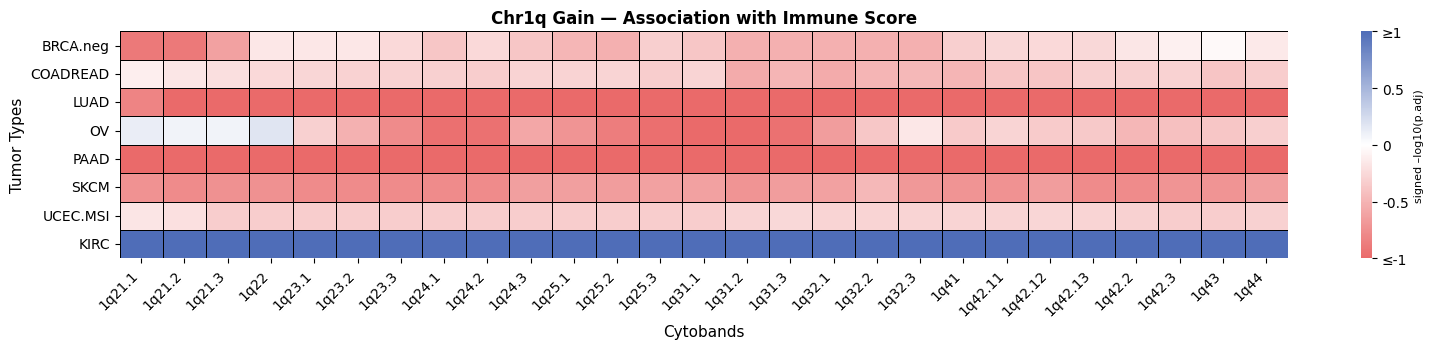

Saved: cytoband_1q_gain_updated.pdf


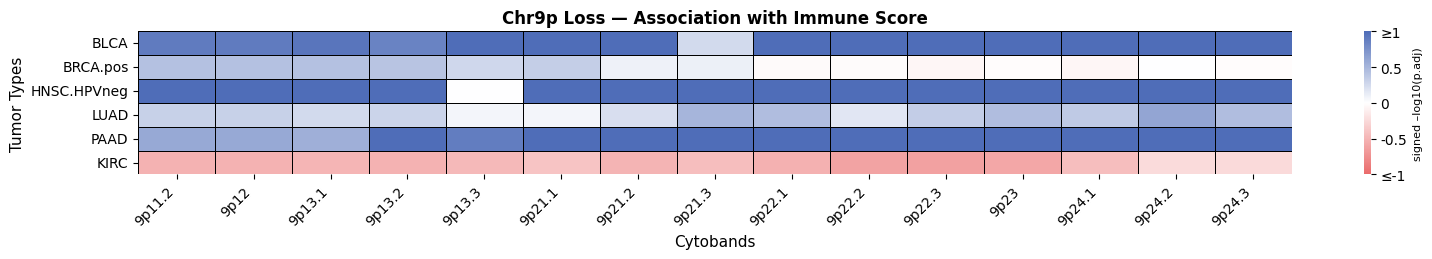

Saved: cytoband_9p_loss_updated.pdf


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
import os

# ── Load data ─────────────────────────────────────────────────────────────────
df = pd.read_excel(
    "/Users/annabelshinichen/Desktop/SchoolWork/MSBMI/Davoli_lab/TCGA/Resubmission_SCNAs/TableS1_TCGA_SampleNum_IS_Regressions_Tables.xlsx",
    sheet_name="IS_LinReg_CytobandCNV"
)

# ── Output directory ──────────────────────────────────────────────────────────
out_dir = "/Users/annabelshinichen/Desktop/SchoolWork/MSBMI/Davoli_lab/TCGA/Resubmission_SCNAs"

# ── Diverging colormap: blue = lower IS, red = higher IS ─────────────────────
diverging_cmap = LinearSegmentedColormap.from_list(
    "custom_diverging", ["#EA6A6A", "#FFFFFF", "#4F6DB8"], N=256
)

# ── Tumor types ───────────────────────────────────────────────────────────────
tumor_types_1q_gain = ['BRCA.neg', 'COADREAD', 'LUAD', 'OV', 'PAAD', 'SKCM', 'UCEC.MSI', 'KIRC']
tumor_types_9p_loss = ['BLCA', 'BRCA.pos', 'HNSC.HPVneg', 'LUAD', 'PAAD', 'KIRC']

panels = [
    {
        "title": "Chr1q Gain — Association with Immune Score",
        "arm": "1q",
        "cnv": 1,
        "tumor_types": tumor_types_1q_gain,
        "filename": "cytoband_1q_gain_updated.pdf",    # ADDED
    },
    {
        "title": "Chr9p Loss — Association with Immune Score",
        "arm": "9p",
        "cnv": -1,
        "tumor_types": tumor_types_9p_loss,
        "filename": "cytoband_9p_loss_updated.pdf",    # ADDED
    },
]

# ── Plot ──────────────────────────────────────────────────────────────────────
for panel in panels:

    filtered = df[
        (df['cnv_status'] == panel['cnv']) &
        (df['Cytoband'].str.startswith(panel['arm'])) &
        (df['TumorType'].isin(panel['tumor_types']))
    ].copy()

    # Use raw signed value — NO abs() so direction is preserved
    # negative = higher CN → lower IS (blue)
    # positive = higher CN → higher IS (red, e.g. KIRC for 1q gain)
    filtered['plot_value'] = filtered['signed (-log(P.adj))']

    # Handle duplicates
    filtered = filtered.groupby(
        ["TumorType", "Cytoband"], as_index=False
    )["plot_value"].mean()

    # Pivot and enforce row order
    pivot = filtered.pivot(
        index="TumorType",
        columns="Cytoband",
        values="plot_value"
    ).fillna(0)
    pivot = pivot.reindex(panel['tumor_types']).fillna(0)

    # Plot
    n_rows = len(panel['tumor_types'])
    fig_height = max(2.5, n_rows * 0.45)

    fig, ax = plt.subplots(figsize=(16, fig_height))
    
    g = sns.heatmap(
    pivot,
    cmap=diverging_cmap,
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    linecolor='black',
    cbar_kws={
        "label": "signed –log10(p.adj)",
        "ticks": [-1, -0.5, 0, 0.5, 1]
    },
    ax=ax
)

    # Force vector (non-rasterized) rendering of the mesh
    for collection in ax.collections:
        collection.set_rasterized(False)

    cbar = g.collections[0].colorbar
    cbar.set_ticks([-1, -0.5, 0, 0.5, 1])
    cbar.set_ticklabels(['≤-1', '-0.5', '0', '0.5', '≥1'])
    cbar.set_label('signed –log10(p.adj)', fontsize=8)

    plt.title(panel['title'], fontsize=12, fontweight='bold')
    plt.xlabel("Cytobands", fontsize=11)
    plt.ylabel("Tumor Types", fontsize=11)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, panel['filename']), format="pdf", bbox_inches="tight")  # ADDED
    plt.show()
    print(f"Saved: {panel['filename']}")  # ADDED

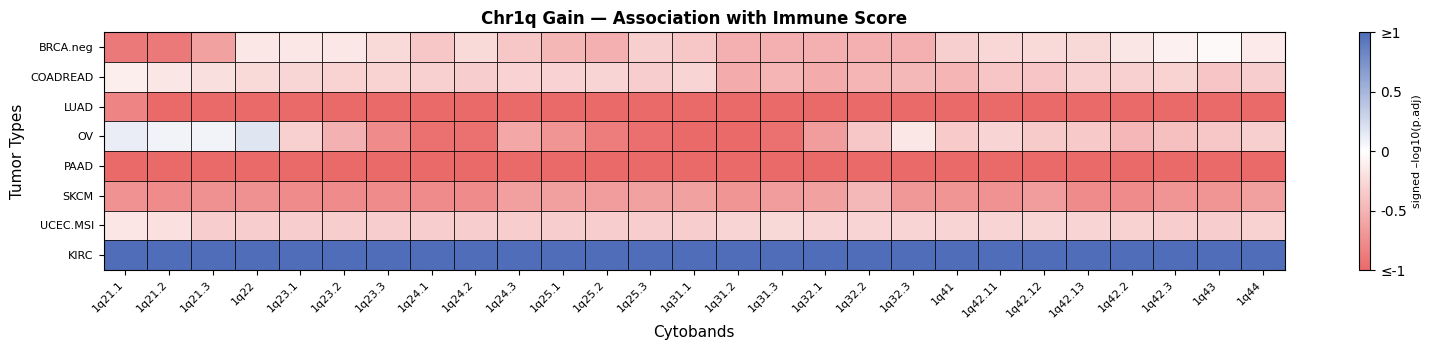

Saved: cytoband_1q_gain_updated.pdf


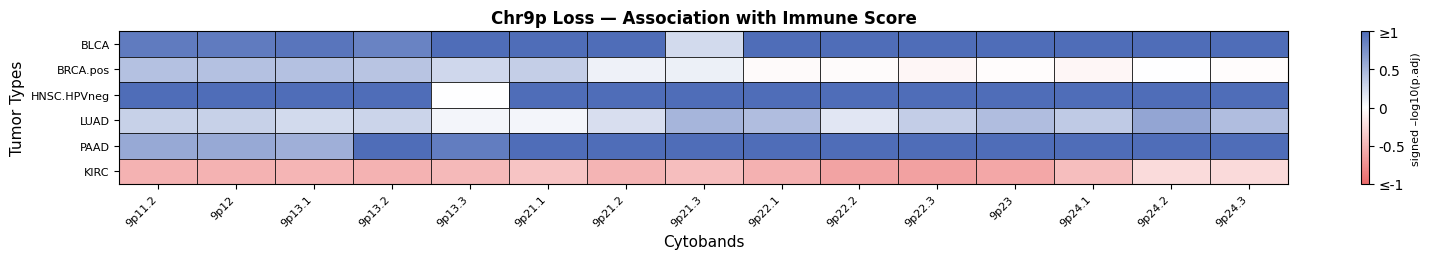

Saved: cytoband_9p_loss_updated.pdf


In [17]:
import matplotlib.patches as mpatches
import matplotlib.colorbar as mcolorbar
import matplotlib.cm as cm
import numpy as np

for panel in panels:

    filtered = df[
        (df['cnv_status'] == panel['cnv']) &
        (df['Cytoband'].str.startswith(panel['arm'])) &
        (df['TumorType'].isin(panel['tumor_types']))
    ].copy()

    filtered['plot_value'] = filtered['signed (-log(P.adj))']
    filtered = filtered.groupby(
        ["TumorType", "Cytoband"], as_index=False
    )["plot_value"].mean()

    pivot = filtered.pivot(
        index="TumorType", columns="Cytoband", values="plot_value"
    ).fillna(0)
    pivot = pivot.reindex(panel['tumor_types']).fillna(0)

    n_rows, n_cols = pivot.shape
    fig_height = max(2.5, n_rows * 0.45)

    fig, ax = plt.subplots(figsize=(16, fig_height))

    norm = plt.Normalize(vmin=-1, vmax=1)

    # ── Draw each cell as an individual Rectangle patch ──────────────────
    for row_idx, tumor in enumerate(pivot.index):
        for col_idx, cytoband in enumerate(pivot.columns):
            val = pivot.loc[tumor, cytoband]
            color = diverging_cmap(norm(val))
            rect = mpatches.FancyBboxPatch(
                (col_idx, n_rows - row_idx - 1),  # x, y bottom-left
                1, 1,                               # width, height
                boxstyle="square,pad=0",
                linewidth=0.5,
                edgecolor='black',
                facecolor=color
            )
            ax.add_patch(rect)

    # ── Axes formatting ───────────────────────────────────────────────────
    ax.set_xlim(0, n_cols)
    ax.set_ylim(0, n_rows)
    ax.set_xticks(np.arange(n_cols) + 0.5)
    ax.set_xticklabels(pivot.columns, rotation=45, ha='right', fontsize=8)
    ax.set_yticks(np.arange(n_rows) + 0.5)
    ax.set_yticklabels(pivot.index[::-1], rotation=0, fontsize=8)

    # ── Colorbar ──────────────────────────────────────────────────────────
    sm = plt.cm.ScalarMappable(cmap=diverging_cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax)
    cbar.set_ticks([-1, -0.5, 0, 0.5, 1])
    cbar.set_ticklabels(['≤-1', '-0.5', '0', '0.5', '≥1'])
    cbar.set_label('signed –log10(p.adj)', fontsize=8)

    ax.set_title(panel['title'], fontsize=12, fontweight='bold')
    ax.set_xlabel("Cytobands", fontsize=11)
    ax.set_ylabel("Tumor Types", fontsize=11)

    plt.tight_layout()

    # Save PDF and SVG
    plt.savefig(os.path.join(out_dir, panel

In [18]:
# Check 9p loss sign values for BLCA
check = df[
    (df['cnv_status'] == -1) &
    (df['Cytoband'].str.startswith('9p')) &
    (df['TumorType'] == 'BLCA')
]
print(check[['Cytoband', 'Coefficients', 'signed (-log(P.adj))', 'ImmuneHit']].head(10))

     Cytoband  Coefficients  signed (-log(P.adj))    ImmuneHit
1205   9p24.3     41.158236              3.429608  Immune Cold
1206   9p24.2     36.500405              3.223760  Immune Cold
1207   9p24.1     33.764166              3.223760  Immune Cold
1208     9p23     38.651553              3.223760  Immune Cold
1209   9p22.3     37.733296              3.139821  Immune Cold
1210   9p22.2     40.327278              3.429608  Immune Cold
1211   9p22.1     39.504765              3.429608  Immune Cold
1212   9p21.3      8.126311              0.256756          NaN
1213   9p21.2     30.431154              1.943139  Immune Cold
1214   9p21.1     35.303125              2.154102  Immune Cold
